<a href="https://colab.research.google.com/github/Raneen-git/Raneen-git/blob/main/Python-Analytics-EU_Pharma_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ehmadali/eu-pharmacy-products-and-pricing")

print("Path to dataset files:", path)


100%|██████████| 3.64M/3.64M [00:00<00:00, 5.47MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ehmadali/eu-pharmacy-products-and-pricing/versions/1


In [6]:
# View all files in the downloaded directory
import os
files = os.listdir(path)
print("Files available in directory:")
for f in files:
    print(f"- {f}")

Files available in directory:
- Pharmacy_data.xlsx


In [7]:

import numpy as np
import pandas as pd

# Path to the file whats
excel_file = os.path.join(path, files[0])
xls = pd.ExcelFile(excel_file)
print("Sheets in the Excel file:")
for sheet in xls.sheet_names:
    print(f"- {sheet}")
# Load the distinct components of the Star Schema
fact_sales = pd.read_excel(excel_file, sheet_name='FactSales')
dim_product = pd.read_excel(excel_file, sheet_name='DimProduct')
dim_pharmacy = pd.read_excel(excel_file, sheet_name='DimPharmacy')
dim_date = pd.read_excel(excel_file, sheet_name='DimDate')

print("Tables successfully loaded from Excel sheets!")


Sheets in the Excel file:
- FactSales
- DimDate
- DimPharmacy
- DimProduct
Tables successfully loaded from Excel sheets!


In [8]:
print(f"FactSales rows: {fact_sales.shape[0]:,}")
print(f"Unique Products: {dim_product.shape[0]}")
print(f"Unique Pharmacies: {dim_pharmacy.shape[0]}")

# Quick view of transaction structure
fact_sales.head()

FactSales rows: 62,139
Unique Products: 220
Unique Pharmacies: 120


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes


In [9]:
#Verifying Integrity
fact_sales.head()

,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes


**Phase 1**: Data Cleaning & Structural Merging
Referential Integrity Check: Confirm every product ID or pharmacy ID in FactSales matches a record in its respective dimension table. Look for missing or anomalous values.

In [10]:
#checking for duplicates
fact_sales['SalesID'].duplicated().sum()
#merging into a single data frame
df_master = pd.merge(fact_sales, dim_product, on='ProductID', how='left')
df_master = pd.merge(df_master, dim_pharmacy, on='PharmacyID', how='left')


In [11]:
import numpy as np

# Create a copy so we don't overwrite your clean master yet
df_dirty = df_master.copy()
np.random.seed(42) # For reproducibility

# 1. Inject Missing Values (Nulls)
# Simulating missing data from certain store POS systems
df_dirty.loc[df_dirty.sample(frac=0.05).index, 'RevenueEUR'] = np.nan
df_dirty.loc[df_dirty.sample(frac=0.02).index, 'StoreSizeBand'] = np.nan

# 2. Inject Outliers & Impossible Values
# Simulating system glitches (negative sales = returns not processed correctly)
df_dirty.loc[df_dirty.sample(frac=0.01).index, 'UnitsSold'] *= -1
# Simulating fat-finger data entry for costs
df_dirty.loc[df_dirty.sample(frac=0.005).index, 'CostEUR'] = 999999

# 3. Inject String/Categorical Inconsistencies
# Mixed casing and trailing spaces in promo flags
df_dirty['PromoFlag'] = df_dirty['PromoFlag'].replace({'Yes': 'YES ', 'No': 'no'})

# 4. Inject Duplicate Rows
# Simulating double-firing ETL pipelines
duplicates = df_dirty.sample(500)
df_dirty = pd.concat([df_dirty, duplicates])

# Shuffle the dataset to scatter the dirt randomly and reset the index
df_dirty = df_dirty.sample(frac=1).reset_index(drop=True)

print("Data successfully made dirty!")
print(f"New row count: {df_dirty.shape[0]:,}")

Data successfully made dirty!
New row count: 62,639


In [12]:
print("--- MISSING VALUES ---")
print(df_dirty.isnull().sum()[df_dirty.isnull().sum() > 0])

--- MISSING VALUES ---
RevenueEUR           3135
DiscontinuedDate    57549
StoreSizeBand        1253
dtype: int64


In [13]:
#getting minmax from these columns
print("\n--- DESCRIPTIVE STATS (Look for min/max anomalies) ---")
# Notice the negative minimum in UnitsSold and the absurd maximum in CostEUR
display(df_dirty[['UnitsSold', 'RevenueEUR', 'CostEUR']].describe())


--- DESCRIPTIVE STATS (Look for min/max anomalies) ---


,UnitsSold,RevenueEUR,CostEUR
count,62639.000000,59504.000000,62639.000000
mean,7.032599,138.973142,5080.452261
std,5.078391,124.569575,70393.176248
min,-23.000000,1.610000,1.100000
25%,3.000000,55.210000,39.465000
50%,6.000000,102.750000,72.600000
75%,10.000000,181.617500,130.220000
max,25.000000,1036.280000,999999.000000


In unit sold min is -23 it is wrong
in Cost EUR max cost is 9999999

In [14]:
print("\n--- CATEGORICAL INCONSISTENCIES ---")

print(df_dirty['PromoFlag'].value_counts())


--- CATEGORICAL INCONSISTENCIES ---
PromoFlag
no      55131
YES      7508
Name: count, dtype: int64


In [15]:
#checking dupliactes
print(f"total duplicates found: {df_dirty.duplicated().sum()}")

total duplicates found: 500


In [16]:
#dropping duplicates
df_clean = df_dirty.copy()
df_clean = df_clean.drop_duplicates()
#no of rows after duplication
print(f"no of rows after removing dupliactes:{df_clean.shape[0]}")


no of rows after removing dupliactes:62139


In [17]:
#Standardize Categorical Strings
# Strip white spaces and enforce Title Case (e.g., 'YES ' -> 'Yes')
df_clean['PromoFlag'] = df_clean['PromoFlag'].str.strip().str.title()
# 3. Handle Missing Values
# For numeric financial data, fill with the median to avoid outlier skew
median_revenue = df_clean['RevenueEUR'].median()
df_clean['RevenueEUR'] = df_clean['RevenueEUR'].fillna(median_revenue)
#fill Na with Unkowns in Storesizeband
df_clean['StoreSizeBand'] = df_clean['StoreSizeBand'].fillna('Unknown')
# Convert negative units to absolute values (assuming they were formatting errors)
df_clean['UnitsSold'] = df_clean['UnitsSold'].abs()



In [18]:
# Cap absurdly high costs at the 99th percentile (Winsorization)
cost_p99 = df_clean['CostEUR'].quantile(0.99)


In [19]:
df_clean.loc[df_clean['CostEUR'] > cost_p99, 'CostEUR'] = cost_p99

In [20]:
print("\nCleaning Complete! Validating fixes:")
print(f"Nulls left:\n{df_clean[['RevenueEUR', 'StoreSizeBand']].isnull().sum()}")
print(f"\nPromoFlag standardized:\n{df_clean['PromoFlag'].value_counts()}")


Cleaning Complete! Validating fixes:
Nulls left:
RevenueEUR       0
StoreSizeBand    0
dtype: int64

PromoFlag standardized:
PromoFlag
No     54708
Yes     7431
Name: count, dtype: int64


--- 90-Day Revenue Forecast ---


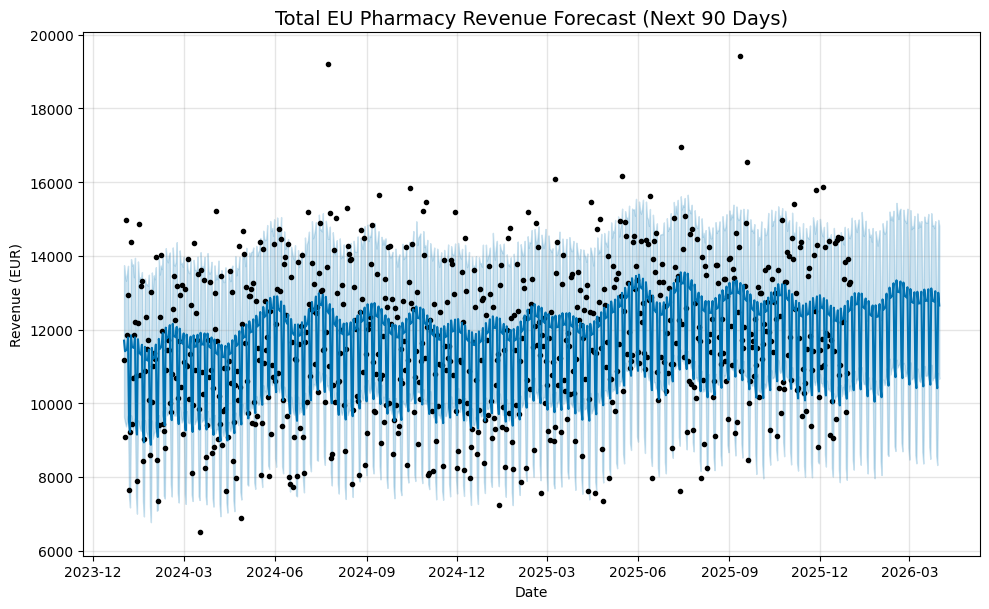


--- Structural Market Trends ---


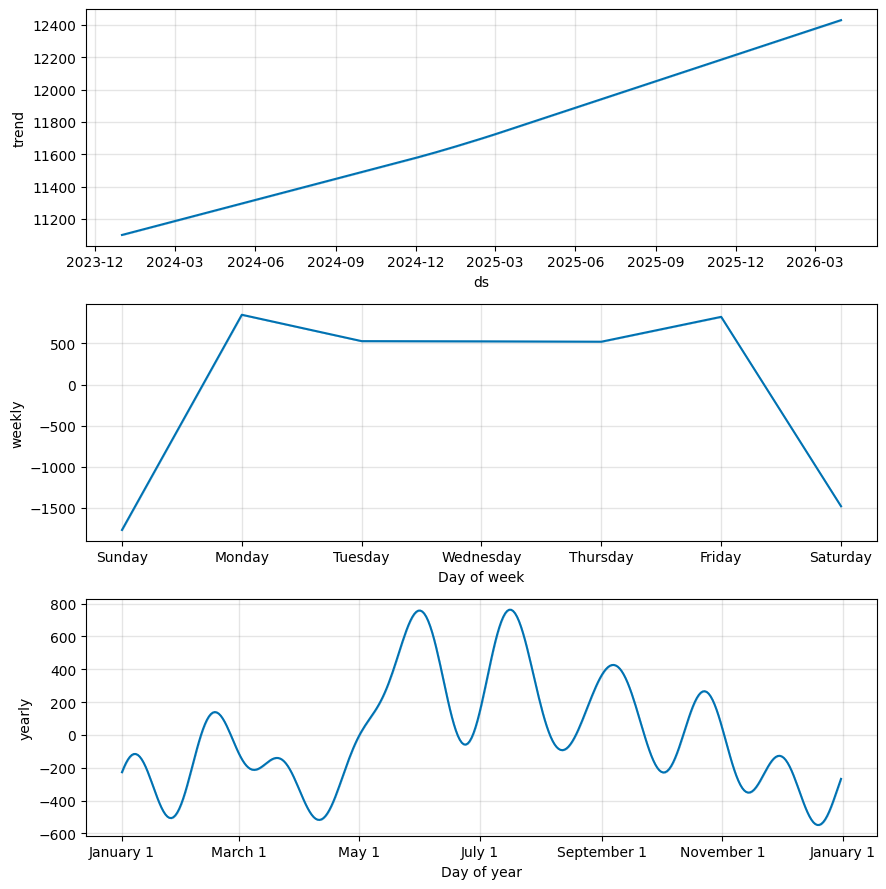

In [21]:
# 1. Import the necessary forecasting and visualization libraries
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd

# 2. Format the Date Column
# Currently, DateKey is likely an integer like 20240101. We need it as a datetime object.
df_clean['Date'] = pd.to_datetime(df_clean['DateKey'].astype(str), format='%Y%m%d')

# 3. Aggregate Data for the Model
# We want to forecast total overall revenue per day
daily_sales = df_clean.groupby('Date')['RevenueEUR'].sum().reset_index()

# 4. Prepare Data for Prophet
# Prophet strictly requires the date column to be named 'ds' and the target variable 'y'
prophet_df = daily_sales.rename(columns={'Date': 'ds', 'RevenueEUR': 'y'})

# 5. Initialize and Train the Model
# We enable yearly seasonality to catch annual pharmaceutical buying cycles
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# 6. Generate the Future Forecast (Next 90 Days)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 7. Visualize the Results
print("--- 90-Day Revenue Forecast ---")
fig1 = model.plot(forecast)
plt.title("Total EU Pharmacy Revenue Forecast (Next 90 Days)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue (EUR)")
plt.show()

# 8. Visualize Trend Components (Weekly & Yearly Trends)
print("\n--- Structural Market Trends ---")
fig2 = model.plot_components(forecast)
plt.show()

In [22]:
# --- 1. PROMOTIONAL ROI (Ad & Discount Cohort Analysis) ---
print("--- PROMOTIONAL EFFECTIVENESS ---")
promo_impact = df_clean.groupby('PromoFlag').agg(
    Avg_Units_Sold=('UnitsSold', 'mean'),
    Avg_Margin_EUR=('MarginEUR', 'mean'),
    Total_Transactions=('SalesID', 'count')
).round(2)
display(promo_impact)

# --- 2. CATALOG OPTIMIZATION (The 80/20 Rule on SKUs) ---
print("\n--- SKU PORTFOLIO OPTIMIZATION ---")
sku_profit = df_clean.groupby('ProductID')['MarginEUR'].sum().sort_values(ascending=False).reset_index()
sku_profit['Cumulative_Margin_%'] = (sku_profit['MarginEUR'].cumsum() / sku_profit['MarginEUR'].sum()) * 100

top_20_percent_count = int(len(sku_profit) * 0.20)
margin_from_top_20 = sku_profit.loc[top_20_percent_count, 'Cumulative_Margin_%']

print(f"Total SKUs in Catalog: {len(sku_profit)}")
print(f"The top 20% of SKUs generate {margin_from_top_20:.1f}% of total portfolio margin.")

# --- 3. STORE FOOTPRINT (Territory Performance) ---
print("\n--- TERRITORY STORE ALIGNMENT ---")
store_perf = df_clean.groupby('StoreSizeBand').agg(
    Total_Revenue=('RevenueEUR', 'sum'),
    Average_Margin=('MarginEUR', 'mean')
).sort_values(by='Total_Revenue', ascending=False).round(2)
display(store_perf)

--- PROMOTIONAL EFFECTIVENESS ---


,Avg_Units_Sold,Avg_Margin_EUR,Total_Transactions
PromoFlag,,,
No,7.19,40.94,54708
Yes,7.02,24.43,7431



--- SKU PORTFOLIO OPTIMIZATION ---
Total SKUs in Catalog: 220
The top 20% of SKUs generate 38.2% of total portfolio margin.

--- TERRITORY STORE ALIGNMENT ---


,Total_Revenue,Average_Margin
StoreSizeBand,,
M,3712451.64,38.16
L,3049041.16,44.97
S,1586312.91,32.17
Unknown,172191.27,39.26
